# Stack Overflow Survey Job Satisfaction Model

This notebook takes the cleaned respondent parquet and walks through the full satisfaction modeling pass directly in the notebook. The goal is to keep the target harmonization, feature choices, preprocessing, feature audit, and model comparisons clear and grounded.


In [1]:
import os
import warnings
from pathlib import Path

# My CPU likely needs some thermal TLC because I'm getting overheating issues
NOTEBOOK_THREAD_CAP = '4'
NOTEBOOK_DEVICE = 'gpu'
NOTEBOOK_GPU_DEVICE = '0'

# Cap thread pools before importing numpy/scipy/lightgbm/catboost
os.environ['SO_NOTEBOOK_THREADS'] = NOTEBOOK_THREAD_CAP
os.environ['SO_NOTEBOOK_DEVICE'] = NOTEBOOK_DEVICE
os.environ['SO_NOTEBOOK_GPU_DEVICE'] = NOTEBOOK_GPU_DEVICE
for env_name in ['OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS']:
    os.environ[env_name] = NOTEBOOK_THREAD_CAP

# Prevent LightGBM from caching GPU kernel
if NOTEBOOK_DEVICE.lower() == 'gpu':
    os.environ.setdefault('BOOST_COMPUTE_USE_OFFLINE_CACHE', '0')

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent

# Keep routine notebook noise down without hiding model failures
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from IPython.display import display
from scipy.linalg import qr
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    recall_score,
)
from statsmodels.miscmodels.ordinal_model import OrderedModel

# Keep tables and plots easy to read
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 120

## Notebook Setup

1. Load `clean_core.parquet` and validate the fields needed for job satisfaction
2. Build the harmonized 5-point target in the notebook and audit year coverage
3. Check broad and candidate feature coverage by year before locking the main spec
4. Freeze the canonical years, feature set, and time-based split
5. Define the local helpers for preprocessing, baselines, feature audit, and candidate models
6. Compare the baseline, ordered model, LightGBM, and CatBoost on the same split
7. Check compensation only as a same-sample sensitivity rather than as part of the headline model
8. Inspect harmonization sensitivity, untouched 2025 diagnostics, and rolling-origin stability


In [3]:
# Define the core constants that keep the satisfaction task and split contract consistent
RANDOM_STATE = 42
ORDERED_MAX_ROWS = 50_000

SAT_TARGET = 'job_sat_std'
SAT_BINARY = 'sat_binary'
SAT_INSTRUMENT = 'job_sat_instrument'
SAT_LABELS = [1, 2, 3, 4, 5]
SAT_BINARY_THRESHOLD = 4

# Read the runtime controls
CPU_THREADS = int(os.environ.get('SO_NOTEBOOK_THREADS', '4'))
TRAIN_DEVICE = os.environ.get('SO_NOTEBOOK_DEVICE', 'cpu').lower()
GPU_DEVICE = os.environ.get('SO_NOTEBOOK_GPU_DEVICE', '0')

# Main satisfaction window and holdout years
SAT_CANONICAL_YEARS = [2015, 2016, 2017, 2018, 2019, 2020, 2024, 2025]
SAT_TRAIN_YEARS = [2015, 2016, 2017, 2018, 2019, 2020]
SAT_VALID_YEAR = 2024
SAT_TEST_YEAR = 2025

# The later-wave 0-10 scales need an explicit collapse into the shared 5-point target
SAT_NUMERIC_SCHEMES = {
    'default': [0, 3, 6, 9],
    'alt_equal_width': [2, 4, 6, 8]
}
SAT_INSTRUMENTS = {
    2015: 'text_5pt',
    2016: 'text_5pt',
    2017: 'numeric_11pt',
    2018: 'text_7pt',
    2019: 'text_5pt',
    2020: 'text_5pt',
    2024: 'numeric_11pt',
    2025: 'numeric_11pt'
}
SAT_MAP = {
    "I hate my job": 1,
    "I'm somewhat dissatisfied with my job": 2,
    "I'm neither satisfied nor dissatisfied with my job": 3,
    "I'm neither satisfied nor dissatisfied": 3,
    "I'm somewhat satisfied with my job": 4,
    "I love my job": 5,
    "I don't have a job": np.nan,
    "Other (please specify)": np.nan,
    'Extremely dissatisfied': 1,
    'Moderately dissatisfied': 2,
    'Slightly dissatisfied': 2,
    'Neither satisfied nor dissatisfied': 3,
    'Slightly satisfied': 4,
    'Moderately satisfied': 4,
    'Extremely satisfied': 5,
    'Very dissatisfied': 1,
    'Very satisfied': 5
}

# Keep the headline model defaults explicit in the notebook
DEFAULT_LGB_PARAMS = {
    'objective': 'multiclass',
    'metric': 'multi_logloss',
    'num_class': len(SAT_LABELS),
    'n_estimators': 400,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.0,
    'reg_lambda': 0.0,
    'class_weight': 'balanced',
    'random_state': RANDOM_STATE,
    'n_jobs': CPU_THREADS,
    'verbosity': -1
}
DEFAULT_CATBOOST_PARAMS = {
    'loss_function': 'MultiClass',
    'eval_metric': 'MultiClass',
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 8,
    'l2_leaf_reg': 5.0,
    'random_seed': RANDOM_STATE,
    'auto_class_weights': 'Balanced',
    'allow_writing_files': False,
    'thread_count': CPU_THREADS,
    'verbose': False
}

# GPU only affects the tree-model sections
if TRAIN_DEVICE == 'gpu':
    DEFAULT_LGB_PARAMS['device_type'] = 'gpu'
    DEFAULT_CATBOOST_PARAMS['task_type'] = 'GPU'
    DEFAULT_CATBOOST_PARAMS['devices'] = GPU_DEVICE

SAT_BASELINE_GROUP_SETS = [['country_clean'], ['region'], []]

# These are the numeric fields that need coercion before modeling
SAT_NUMERIC_FIELDS = [
    'age_mid',
    'years_code_clean',
    'professional_experience_years',
    'years_code_pro_clean',
    'work_exp_clean',
    'career_start_age_est',
    'coding_start_age_est',
    'pro_to_total_code_ratio',
    'language_count',
    'database_count',
    'platform_count',
    'role_family_count',
    'log_comp_real_2025'
]
MULTI_COUNT_MAP = {
    'language': 'language_count',
    'database': 'database_count',
    'platform': 'platform_count',
    'webframe': 'webframe_count',
    'misc_tech': 'misc_tech_count',
    'learn_code': 'learn_code_count',
    'learn_code_online': 'learn_code_online_count',
    'coding_activities': 'coding_activities_count',
    'op_sys_prof': 'op_sys_prof_count'
}
ROLE_FAMILY_LEVELS = [
    'Advocacy / DX',
    'Architecture',
    'Back-end',
    'Data / ML',
    'Design / UX',
    'Desktop / Enterprise',
    'DevOps / Cloud',
    'Embedded / hardware',
    'Front-end',
    'Full-stack',
    'Game / graphics',
    'Management',
    'Mobile',
    'Other',
    'QA / Testing',
    'Security',
    'Student / Academic'
]
ROLE_FAMILY_COLS = {
    level: 'role_' + ''.join(ch if ch.isalnum() else '_' for ch in level.lower()).strip('_').replace('__', '_')
    for level in ROLE_FAMILY_LEVELS
}
print("Thread cap:", CPU_THREADS)
print("Tree-model device:", TRAIN_DEVICE)
if TRAIN_DEVICE == 'gpu':
    print("GPU device:", GPU_DEVICE)

Thread cap: 4
Tree-model device: gpu
GPU device: 0


## Load Finalized Clean Core

Double checks that `clean_core.parquet` exists and that the satisfaction fields we need are there before modeling starts.


In [4]:
# Load the cleaned respondent table and validate the columns needed
CLEAN_PATH = ROOT / 'data' / 'derived' / 'clean_core.parquet'
clean_core = pd.read_parquet(CLEAN_PATH).copy()

required_cols = {
    'survey_year',
    'job_sat',
    'is_professional',
    'employment_primary',
    'is_full_time_employed',
    'is_part_time_employed',
    'is_independent',
    'region',
    'country_clean',
    'age_mid',
    'education_clean',
    'org_size_clean',
    'remote_group',
    'years_code_clean',
    'language',
    'database',
    'platform',
    'comp_real_2025'
}
missing_cols = sorted(required_cols - set(clean_core.columns))
assert not missing_cols, f'Missing required columns: {missing_cols}'

# Keep string columns consistently nullable for the later prep steps
string_cols = clean_core.select_dtypes(include='string').columns
clean_core[string_cols] = clean_core[string_cols].fillna(pd.NA)

print('clean_core shape:', clean_core.shape)
display(clean_core[['survey_year', 'job_sat', 'country_clean', 'employment_primary']].head())

clean_core shape: (746226, 64)


,survey_year,job_sat,country_clean,employment_primary
0,2015,I'm somewhat satisfied with my job,Croatia,Employed full-time
1,2015,I'm neither satisfied nor dissatisfied with my...,France,Employed full-time
2,2015,I'm somewhat satisfied with my job,India,Independent / contract
3,2015,I'm somewhat satisfied with my job,Latvia,Employed full-time
4,2015,I love my job,Norway,Employed full-time


## Target Harmonization And Modeling Frame

These are the main functions that will be used across models to create split roles, employment flags, and standardize the satisfaction target.


In [5]:
# Build role family based on respondent dev_type
def build_role_family_value(value):
    if pd.isna(value):
        return pd.NA

    families = []
    seen = set()
    for token in str(value).split(';'):
        text = token.strip().lower()
        if not text:
            continue

        if 'architect' in text:
            family = 'Architecture'
        elif 'developer advocate' in text or 'developer experience' in text or 'devrel' in text:
            family = 'Advocacy / DX'
        elif 'designer' in text or 'ux' in text or 'ui' in text:
            family = 'Design / UX'
        elif 'embedded' in text or 'firmware' in text or 'hardware' in text:
            family = 'Embedded / hardware'
        elif 'game' in text or 'graphics' in text:
            family = 'Game / graphics'
        elif 'full-stack' in text or 'web developer' in text:
            family = 'Full-stack'
        elif 'back-end' in text or 'backend' in text or 'server' in text:
            family = 'Back-end'
        elif 'front-end' in text or 'frontend' in text:
            family = 'Front-end'
        elif 'data' in text or 'machine learning' in text or 'scientist' in text or 'analyst' in text or 'ai/ml' in text:
            family = 'Data / ML'
        elif 'mobile' in text or 'ios' in text or 'android' in text:
            family = 'Mobile'
        elif any(term in text for term in ['devops', 'site reliability', 'cloud', 'system administrator', 'systems administrator', 'sysadmin']):
            family = 'DevOps / Cloud'
        elif 'desktop' in text or 'enterprise' in text:
            family = 'Desktop / Enterprise'
        elif 'security' in text:
            family = 'Security'
        elif 'manager' in text or 'executive' in text:
            family = 'Management'
        elif 'student' in text or 'academic researcher' in text or 'educator' in text:
            family = 'Student / Academic'
        elif 'qa' in text or 'quality assurance' in text or 'test' in text:
            family = 'QA / Testing'
        else:
            family = 'Other'

        if family in seen:
            continue
        seen.add(family)
        families.append(family)

    return ';'.join(families) if families else pd.NA


# Determine whether respondents are paid workers based on employment status
def paid_work_mask(frame):
    flag_cols = ['is_full_time_employed', 'is_part_time_employed', 'is_independent']
    if set(flag_cols).issubset(frame.columns):
        return frame[flag_cols].fillna(False).astype(bool).any(axis=1)

    return frame['employment_primary'].isin([
        'Employed full-time',
        'Employed part-time',
        'Independent / contract'
    ])


# Main function to standardize the job satisfaction variable into a common target
def add_job_sat_std(frame, numeric_scheme='default'):
    out = frame.copy()
    out[SAT_INSTRUMENT] = out['survey_year'].map(SAT_INSTRUMENTS)

    standardized = []
    for value, year in zip(out['job_sat'], out['survey_year'], strict=False):
        if pd.isna(value):
            standardized.append(np.nan)
            continue

        if SAT_INSTRUMENTS.get(year) == 'numeric_11pt':
            try:
                numeric = float(value)
            except (TypeError, ValueError):
                standardized.append(np.nan)
                continue

            cutoffs = SAT_NUMERIC_SCHEMES[numeric_scheme]
            if numeric <= cutoffs[0]:
                standardized.append(1)
            elif numeric <= cutoffs[1]:
                standardized.append(2)
            elif numeric <= cutoffs[2]:
                standardized.append(3)
            elif numeric <= cutoffs[3]:
                standardized.append(4)
            else:
                standardized.append(5)
        else:
            standardized.append(SAT_MAP.get(value, np.nan))

    out[SAT_TARGET] = standardized
    return out



# Main function to build the satisfaction modeling frame with all the features and filters applied
def build_satisfaction_frame(
    clean_frame,
    include_years=None,
    numeric_scheme='default',
    drop_2018=False,
    require_professional=True,
    require_employed=True,
    add_binary_target=True,
    binary_threshold=SAT_BINARY_THRESHOLD
):
    include_years = SAT_CANONICAL_YEARS if include_years is None else include_years
    frame = add_job_sat_std(clean_frame, numeric_scheme=numeric_scheme)

    age_mid = pd.to_numeric(frame.get('age_mid', pd.Series(pd.NA, index=frame.index)), errors='coerce')
    years_code = pd.to_numeric(frame.get('years_code_clean', pd.Series(pd.NA, index=frame.index)), errors='coerce')
    prof_exp = pd.to_numeric(frame.get('professional_experience_years', pd.Series(pd.NA, index=frame.index)), errors='coerce')
    frame['age_mid'] = age_mid
    frame['professional_experience_years'] = prof_exp
    frame['career_start_age_est'] = age_mid - prof_exp
    frame['coding_start_age_est'] = age_mid - years_code
    ratio = (prof_exp / years_code).where(years_code.ne(0))
    frame['pro_to_total_code_ratio'] = pd.Series(ratio, index=frame.index).replace([np.inf, -np.inf], np.nan)
    frame['age_group'] = pd.cut(
        age_mid,
        bins=[10, 25, 35, 45, 55, 100],
        labels=['Under 25', '25-34', '35-44', '45-54', '55+'],
        right=False
    )

    if 'role_family' not in frame.columns:
        frame['role_family'] = pd.NA
    if frame['role_family'].isna().all() and 'dev_type' in frame.columns:
        frame['role_family'] = frame['dev_type'].map(build_role_family_value)

    for source_col, count_col in MULTI_COUNT_MAP.items():
        if source_col not in frame.columns:
            continue

        counts = (
            frame[source_col]
            .fillna('')
            .astype(str)
            .str.split(';')
            .map(lambda items: sum(item.strip() not in {'', 'nan'} for item in items))
        )
        frame[count_col] = counts.where(frame[source_col].notna(), np.nan)

    role_family_text = (
        ';'
        + frame['role_family']
        .fillna('')
        .astype(str)
        .str.replace(r'\s*;\s*', ';', regex=True)
        .str.strip('; ')
        + ';'
    )
    role_family_count = (
        frame['role_family']
        .fillna('')
        .astype(str)
        .str.split(';')
        .map(lambda items: sum(item.strip() not in {'', 'nan'} for item in items))
    )
    frame['role_family_count'] = role_family_count.where(frame['role_family'].notna(), np.nan)
    for level, col in ROLE_FAMILY_COLS.items():
        frame[col] = role_family_text.str.contains(f';{level};', regex=False, na=False).astype(int)

    comp_real = pd.to_numeric(frame.get('comp_real_2025', pd.Series(np.nan, index=frame.index)), errors='coerce')
    frame['log_comp_real_2025'] = np.where(comp_real.notna(), np.log(comp_real), np.nan)

    frame = frame.loc[frame['survey_year'].isin(include_years)].copy()
    if drop_2018:
        frame = frame.loc[frame['survey_year'].ne(2018)].copy()
    frame = frame.loc[frame[SAT_TARGET].notna()].copy()

    if require_professional:
        frame = frame.loc[frame['is_professional']].copy()
    if require_employed:
        frame = frame.loc[paid_work_mask(frame)].copy()

    frame[SAT_TARGET] = frame[SAT_TARGET].astype(int)
    frame['survey_year_str'] = frame['survey_year'].astype('string')

    if add_binary_target:
        frame[SAT_BINARY] = frame[SAT_TARGET].ge(binary_threshold).astype(int)

    return frame

Build the feature sets for the different approaches and create the main DataFrame.

In [7]:
# Builds the feature sets used for different modeling approaches
def build_feature_sets(role_cols):
    core_no_comp_cat = [
        'survey_year_str',
        'region',
        'country_clean',
        'age_group',
        'education_clean',
        'employment_primary',
        'org_size_clean',
        'remote_group'
    ]
    core_no_comp_num = [
        'age_mid',
        'years_code_clean',
        'professional_experience_years',
        'career_start_age_est',
        'coding_start_age_est',
        'pro_to_total_code_ratio',
        'language_count',
        'database_count',
        'platform_count',
        'role_family_count'
    ] + role_cols

    return {
        'core_no_comp_cat': core_no_comp_cat,
        'core_no_comp_num': core_no_comp_num,
        'core_with_comp_cat': core_no_comp_cat.copy(),
        'core_with_comp_num': core_no_comp_num + ['log_comp_real_2025'],
        'ordered_cat': [
            'survey_year_str',
            'region',
            'age_group',
            'education_clean',
            'employment_primary',
            'org_size_clean',
            'remote_group'
        ],
        'ordered_num': ['years_code_clean']
    }


sat_df = build_satisfaction_frame(clean_core)
role_cols = sorted(col for col in sat_df.columns if col.startswith('role_') and col not in {'role_family', 'role_family_count'})
feature_sets = build_feature_sets(role_cols)
core_cat = feature_sets['core_no_comp_cat']
core_num = feature_sets['core_no_comp_num']
core_with_comp_cat = feature_sets['core_with_comp_cat']
core_with_comp_num = feature_sets['core_with_comp_num']
ordered_cat = feature_sets['ordered_cat']
ordered_num = feature_sets['ordered_num']

print("Main satisfaction model rows:", len(sat_df))
print("Role flags used:", len(role_cols))

Main satisfaction model rows: 313011
Role flags used: 17


Display overall yearly summaries of main satisfaction targets.

Yearly breakdown of non-null resonses for standardized frames:


,survey_year,rows,raw_non_null,harmonized_non_null,employed_prof_non_null
0,2015,26086,16174,16004,15509
1,2016,56030,40110,39425,37813
2,2017,51392,40376,40376,39648
3,2018,98855,69276,69276,63347
4,2019,88883,70988,70988,63583
5,2020,64461,45194,45194,40661
6,2024,65437,29126,29126,27029
7,2025,49191,26670,26670,25421



Satisfaction class counts by year:


job_sat_std,survey_year,1,2,3,4,5
0,2015,289,1535,1731,6346,5608
1,2016,778,4334,4211,15831,12659
2,2017,452,2819,10139,22152,4086
3,2018,2297,12393,4367,32881,11409
4,2019,4321,9520,7736,21810,20196
5,2020,3341,6368,5150,12543,13259
6,2024,270,2002,6210,16456,2091
7,2025,143,1288,5535,15663,2792



Satisfaction class proportions by year:


job_sat_std,survey_year,1,2,3,4,5
0,201500,1.86,9.90,11.16,40.92,36.16
1,201600,2.06,11.46,11.14,41.87,33.48
2,201700,1.14,7.11,25.57,55.87,10.31
3,201800,3.63,19.56,6.89,51.91,18.01
4,201900,6.80,14.97,12.17,34.30,31.76
5,202000,8.22,15.66,12.67,30.85,32.61
6,202400,1.00,7.41,22.98,60.88,7.74
7,202500,0.56,5.07,21.77,61.61,10.98


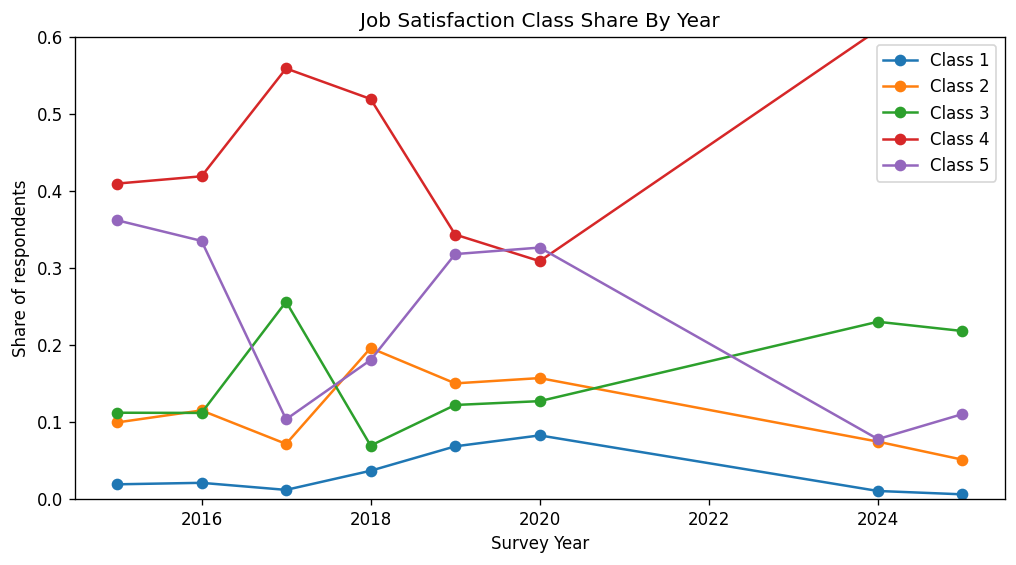

In [8]:
summary_frame = add_job_sat_std(clean_core)
summary_frame = summary_frame.loc[summary_frame['survey_year'].isin(SAT_CANONICAL_YEARS)].copy()
employed_mask = paid_work_mask(summary_frame)

year_summary = (
    summary_frame
    .groupby('survey_year')
    .agg(
        rows=('survey_year', 'size'),
        raw_non_null=('job_sat', lambda series: int(series.notna().sum())),
        harmonized_non_null=(SAT_TARGET, lambda series: int(series.notna().sum())),
        employed_prof_non_null=(
            SAT_TARGET,
            lambda series: int(
                series.loc[
                    summary_frame.loc[series.index, 'is_professional']
                    & employed_mask.loc[series.index]
                ].notna().sum()
            )
        )
    )
    .reset_index()
)

print("Yearly breakdown of non-null resonses for standardized frames:")
display(year_summary)

class_counts = (
    sat_df
    .groupby('survey_year')[SAT_TARGET]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=SAT_LABELS, fill_value=0)
    .reset_index()
)
class_props = class_counts.copy()
class_props[SAT_LABELS] = class_props[SAT_LABELS].div(class_props[SAT_LABELS].sum(axis=1), axis=0)

print("\nSatisfaction class counts by year:")
display(class_counts)
print("\nSatisfaction class proportions by year:")
display(class_props.mul(100).round(2))

plt.figure(figsize=(10, 5))
for label in SAT_LABELS:
    plt.plot(class_props['survey_year'], class_props[label], marker='o', label=f'Class {label}')
plt.title("Job Satisfaction Class Share By Year")
plt.xlabel("Survey Year")
plt.ylabel("Share of respondents")
plt.ylim(0, 0.6)
plt.legend()
plt.show()

## Final Satisfaction Task And Split Choice

The main task should use every year where the target can standardized to the same 5-point scale: `2015-2020, 2024, 2025`. `2021-2023` stay out because they have no satisfaction data. The data splits must be done by year since the dataset is a yearly cross-sectional study: `2015-2020` train, `2024` validation, `2025` final test. Compensation is not included as a feature in the main model because the population is already slimmed to employed professionals for realistic satisfaction responses; including compensation would both shift that population and likely outweigh other broader features.


In [9]:
# Check feature coverage in the final satisfaction window before locking model
availability_cols = [
    'region',
    'country_clean',
    'age_group',
    'education_clean',
    'employment_primary',
    'org_size_clean',
    'remote_group',
    'age_mid',
    'years_code_clean',
    'professional_experience_years',
    'career_start_age_est',
    'coding_start_age_est',
    'pro_to_total_code_ratio',
    'language_count',
    'database_count',
    'platform_count',
    'role_family_count',
    'main_branch',
    'student',
    'undergrad_major',
    'industry_clean',
    'ic_or_pm_clean',
    'webframe_count',
    'misc_tech_count',
    'learn_code_count',
    'learn_code_online_count',
    'coding_activities_count',
    'op_sys_prof_count',
    'ai_use',
    'ai_sent',
    'log_comp_real_2025'
]

# Check coverage of key features across each year to determine what is usable
availability_rows = []
for year in sorted(sat_df['survey_year'].unique()):
    sub = sat_df.loc[sat_df['survey_year'].eq(year)].copy()
    row = {'survey_year': year, 'rows': len(sub)}
    for col in availability_cols:
        row[col] = round(float(sub[col].notna().mean()), 3) if col in sub.columns else np.nan
    availability_rows.append(row)
availability_table = pd.DataFrame(availability_rows)

print("Feature availability in the satisfaction modeling frame by year:")
display(availability_table)

feature_view = pd.DataFrame({
    'core_no_comp_cat': pd.Series(core_cat),
    'core_no_comp_num': pd.Series(core_num),
    'ordered_cat': pd.Series(ordered_cat),
    'ordered_num': pd.Series(ordered_num)
})

print("\nCategorical and numeric feature sets for the main model and ordered baseline:")
display(feature_view)

print("\nUncertain candidate decisions for the main model")
candidate_pool = pd.DataFrame([
    {'candidate': 'age_mid', 'status': 'Promoted', 'reason': 'Broad support and stable lift'},
    {'candidate': 'professional_experience_years', 'status': 'Promoted', 'reason': 'Broad support and pairs well with age features'},
    {'candidate': 'career_start_age_est', 'status': 'Promoted', 'reason': 'Useful career proxy from age and experience'},
    {'candidate': 'coding_start_age_est', 'status': 'Promoted', 'reason': 'Useful coding proxy from age and years coding'},
    {'candidate': 'pro_to_total_code_ratio', 'status': 'Promoted', 'reason': 'Useful experience mix proxy'},
    {'candidate': 'undergrad_major', 'status': 'Side candidate', 'reason': 'Small and mixed lift, not decisive enough to lock in'},
    {'candidate': 'student', 'status': 'Side candidate', 'reason': 'Mixed signal, limited value with employed population'},
    {'candidate': 'main_branch', 'status': 'Side candidate', 'reason': 'Patchy early coverage and standardization'},
    {'candidate': 'industry_clean', 'status': 'Side candidate', 'reason': 'Sparse across the train years'},
    {'candidate': 'ic_or_pm_clean', 'status': 'Side candidate', 'reason': 'Only appears in later years'},
    {'candidate': 'webframe_count / misc_tech_count', 'status': 'Rejected', 'reason': 'Later years only and unstable benefit'},
    {'candidate': 'AI and learning fields', 'status': 'Rejected', 'reason': 'Not available in the train years'}
])
display(candidate_pool)

Feature availability in the satisfaction modeling frame by year:


,survey_year,rows,region,country_clean,age_group,education_clean,employment_primary,org_size_clean,remote_group,age_mid,years_code_clean,professional_experience_years,career_start_age_est,coding_start_age_est,pro_to_total_code_ratio,language_count,database_count,platform_count,role_family_count,main_branch,student,undergrad_major,industry_clean,ic_or_pm_clean,webframe_count,misc_tech_count,learn_code_count,learn_code_online_count,coding_activities_count,op_sys_prof_count,ai_use,ai_sent,log_comp_real_2025
0,2015,15509,0.987,0.987,0.991,0.922,1.0,0.000,0.996,0.991,0.999,0.000,0.000,0.990,0.000,0.979,0.312,0.494,0.929,0.0,0.000,0.000,0.990,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.814
1,2016,37813,0.996,0.996,0.995,0.953,1.0,0.977,0.998,0.995,0.995,0.995,0.991,0.991,0.995,0.979,0.336,0.531,0.995,0.0,0.000,0.000,0.992,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.904
2,2017,39648,0.998,0.999,0.000,0.991,1.0,0.864,0.956,0.000,0.985,0.913,0.000,0.000,0.907,0.755,0.629,0.600,0.882,1.0,1.000,0.914,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.316
3,2018,63347,0.999,0.999,0.805,0.986,1.0,0.883,0.000,0.805,0.999,0.992,0.799,0.804,0.991,0.885,0.775,0.769,0.993,0.0,0.989,0.911,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.850,0.652
4,2019,63583,0.999,0.999,0.913,0.983,1.0,0.977,0.939,0.913,0.996,0.983,0.902,0.912,0.982,0.993,0.890,0.926,0.992,1.0,0.989,0.918,0.000,0.000,0.799,0.705,0.000,0.000,0.0,0.000,0.000,0.000,0.768
5,2020,40661,0.999,0.999,0.808,0.982,1.0,0.980,0.000,0.808,0.993,0.983,0.800,0.805,0.981,0.943,0.849,0.901,0.994,1.0,0.000,0.928,0.000,0.000,0.757,0.696,0.000,0.000,0.0,0.000,0.000,0.000,0.758
6,2024,27029,1.000,1.000,0.996,1.000,1.0,0.960,1.000,0.996,0.998,1.000,0.996,0.995,0.998,0.997,0.883,0.770,0.999,1.0,0.000,0.000,0.987,0.997,0.808,0.697,0.999,0.833,1.0,0.945,1.000,0.767,0.547
7,2025,25421,0.969,0.969,0.998,0.999,1.0,0.886,0.897,0.998,0.989,0.982,0.980,0.987,0.975,0.890,0.756,0.692,1.000,1.0,0.000,0.000,0.998,0.885,0.689,0.000,0.718,0.000,0.0,0.832,0.936,0.930,0.732



Categorical and numeric feature sets for the main model and ordered baseline:


,core_no_comp_cat,core_no_comp_num,ordered_cat,ordered_num
0,survey_year_str,age_mid,survey_year_str,years_code_clean
1,region,years_code_clean,region,NaN
2,country_clean,professional_experience_years,age_group,NaN
3,age_group,career_start_age_est,education_clean,NaN
4,education_clean,coding_start_age_est,employment_primary,NaN
5,employment_primary,pro_to_total_code_ratio,org_size_clean,NaN
6,org_size_clean,language_count,remote_group,NaN
7,remote_group,database_count,NaN,NaN
8,NaN,platform_count,NaN,NaN
9,NaN,role_family_count,NaN,NaN



Uncertain candidate decisions for the main model


,candidate,status,reason
0,age_mid,Promoted,Broad support and stable lift
1,professional_experience_years,Promoted,Broad support and pairs well with age features
2,career_start_age_est,Promoted,Useful career proxy from age and experience
3,coding_start_age_est,Promoted,Useful coding proxy from age and years coding
4,pro_to_total_code_ratio,Promoted,Useful experience mix proxy
5,undergrad_major,Side candidate,"Small and mixed lift, not decisive enough to l..."
6,student,Side candidate,"Mixed signal, limited value with employed popu..."
7,main_branch,Side candidate,Patchy early coverage and standardization
8,industry_clean,Side candidate,Sparse across the train years
9,ic_or_pm_clean,Side candidate,Only appears in later years


In [10]:
# Keep model comparison on the same yearly split
def split_years(frame, train_years, valid_year, test_year):
    train = frame.loc[frame['survey_year'].isin(train_years)].copy()
    valid = frame.loc[frame['survey_year'] == valid_year].copy()
    test = frame.loc[frame['survey_year'] == test_year].copy()
    return train, valid, test


# Use the same scoring block across baselines, tree models, and sensitivity runs
def score_satisfaction(y_true, y_pred, labels=SAT_LABELS):
    y_true = pd.Series(y_true).astype(int)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(int)
    abs_err = (y_true - y_pred).abs()
    recalls = recall_score(y_true, y_pred, labels=labels, average=None, zero_division=0)

    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, labels=labels, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, labels=labels, average='weighted', zero_division=0),
        'qwk': cohen_kappa_score(y_true, y_pred, labels=labels, weights='quadratic'),
        'adjacent_error_rate': float(abs_err.eq(1).mean()),
        'far_miss_rate': float(abs_err.ge(2).mean())
    }

    for label, recall in zip(labels, recalls, strict=False):
        metrics[f'recall_{label}'] = float(recall)

    return metrics


# Flatten model outputs into a comparison table format
def result_row(setup, result):
    if result is None:
        return {
            'setup': setup,
            'valid_qwk': np.nan,
            'valid_macro_f1': np.nan,
            'test_qwk': np.nan,
            'test_macro_f1': np.nan,
            'test_weighted_f1': np.nan,
            'test_accuracy': np.nan,
            'test_adjacent_error_rate': np.nan,
            'test_far_miss_rate': np.nan
        }

    return {
        'setup': setup,
        'valid_qwk': result['valid_metrics']['qwk'],
        'valid_macro_f1': result['valid_metrics']['macro_f1'],
        'test_qwk': result['test_metrics']['qwk'],
        'test_macro_f1': result['test_metrics']['macro_f1'],
        'test_weighted_f1': result['test_metrics']['weighted_f1'],
        'test_accuracy': result['test_metrics']['accuracy'],
        'test_adjacent_error_rate': result['test_metrics']['adjacent_error_rate'],
        'test_far_miss_rate': result['test_metrics']['far_miss_rate']
    }


def metric_table(rows):
    return pd.DataFrame(rows).sort_values(['valid_qwk', 'valid_macro_f1'], ascending=False)


train_df, valid_df, test_df = split_years(sat_df, SAT_TRAIN_YEARS, SAT_VALID_YEAR, SAT_TEST_YEAR)
split_counts = pd.DataFrame([
    {'split': 'train', 'years': '2015-2020', 'rows': len(train_df)},
    {'split': 'valid', 'years': '2024', 'rows': len(valid_df)},
    {'split': 'test', 'years': '2025', 'rows': len(test_df)}
])
display(split_counts)

,split,years,rows
0,train,2015-2020,260561
1,valid,2024,27029
2,test,2025,25421


## Tree-Model Prep And Fitting

The remaining comparisons reuse the same LightGBM and CatBoost prep, so those steps live together here rather than getting repeated in every later section.


In [11]:
# Coerce the fields the tree models expect before each fit
def coerce_satisfaction_frame(frame):
    out = frame.copy()

    if 'survey_year_str' not in out.columns:
        out['survey_year_str'] = out['survey_year'].astype('string')

    numeric_fields = SAT_NUMERIC_FIELDS + [col for col in out.columns if col.startswith('role_')]
    for col in numeric_fields:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')

    if SAT_TARGET in out.columns:
        out[SAT_TARGET] = pd.to_numeric(out[SAT_TARGET], errors='coerce')

    return out


# Save the numeric prep so folds with fully missing columns stay aligned
def fit_numeric_prep(frame, num_cols):
    observed_cols = [col for col in num_cols if frame[col].notna().any()]
    all_missing_cols = [col for col in num_cols if col not in observed_cols]
    imputer = None

    num_df = pd.DataFrame(index=frame.index)
    if observed_cols:
        imputer = SimpleImputer(strategy='median')
        observed = pd.DataFrame(
            imputer.fit_transform(frame[observed_cols]),
            columns=observed_cols,
            index=frame.index
        )
        num_df[observed_cols] = observed

    for col in all_missing_cols:
        num_df[col] = 0.0

    return num_df.reindex(columns=num_cols), {
        'imputer': imputer,
        'observed_cols': observed_cols,
        'all_missing_cols': all_missing_cols
    }


# Apply the same numeric prep to new frames, filling fully missing columns with 0 as before
def transform_numeric_prep(frame, num_cols, num_prep):
    observed_cols = num_prep['observed_cols']
    all_missing_cols = num_prep['all_missing_cols']
    imputer = num_prep['imputer']
    num_df = pd.DataFrame(index=frame.index)

    if observed_cols:
        observed = pd.DataFrame(
            imputer.transform(frame[observed_cols]),
            columns=observed_cols,
            index=frame.index
        )
        num_df[observed_cols] = observed

    for col in all_missing_cols:
        num_df[col] = 0.0

    return num_df.reindex(columns=num_cols)


# LightGBM keeps categoricals native and gets median-imputed numerics
def prepare_lgbm_frame(frame, cat_cols, num_cols, target_col=SAT_TARGET):
    out = coerce_satisfaction_frame(frame)

    for col in cat_cols:
        out[col] = out[col].astype('string').fillna('Missing').astype('category')

    out_num, num_prep = fit_numeric_prep(out, num_cols)
    out[num_cols] = out_num
    if target_col in out.columns:
        out[target_col] = pd.to_numeric(out[target_col], errors='coerce').astype(int)
    return out, num_prep


# Apply the same prep to new frames
def transform_lgbm_frame(frame, cat_cols, num_cols, num_prep, target_col=SAT_TARGET):
    out = coerce_satisfaction_frame(frame)

    for col in cat_cols:
        out[col] = out[col].astype('string').fillna('Missing').astype('category')

    out_num = transform_numeric_prep(out, num_cols, num_prep)
    out[num_cols] = out_num
    if target_col in out.columns:
        out[target_col] = pd.to_numeric(out[target_col], errors='coerce').astype(int)
    return out


# CatBoost uses the same numeric prep but keeps categoricals as strings
def prepare_catboost_frame(frame, cat_cols, num_cols, target_col=SAT_TARGET, num_prep=None):
    out = coerce_satisfaction_frame(frame)

    for col in cat_cols:
        out[col] = out[col].astype('string').fillna('Missing')

    if num_prep is None:
        out_num, num_prep = fit_numeric_prep(out, num_cols)
    else:
        out_num = transform_numeric_prep(out, num_cols, num_prep)

    out[num_cols] = out_num
    if target_col in out.columns:
        out[target_col] = pd.to_numeric(out[target_col], errors='coerce').astype(int)
    return out, num_prep


# Fit LightGBM with early stopping on val set, then refit on train+val and evaluate on test
def fit_lgbm_multiclass(train_df, valid_df, test_df, cat_cols, num_cols, params=None, early_stopping_rounds=50):
    resolved = dict(DEFAULT_LGB_PARAMS)
    if params is not None:
        resolved.update(params)

    train_prepped, num_prep = prepare_lgbm_frame(train_df, cat_cols, num_cols)
    valid_prepped = transform_lgbm_frame(valid_df, cat_cols, num_cols, num_prep)
    features = cat_cols + num_cols

    early_model = lgb.LGBMClassifier(**resolved)
    early_model.fit(
        train_prepped[features],
        train_prepped[SAT_TARGET].to_numpy(),
        eval_set=[(valid_prepped[features], valid_prepped[SAT_TARGET].to_numpy())],
        callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)]
    )
    best_iteration = early_model.best_iteration_ or resolved['n_estimators']
    valid_pred = pd.Series(
        early_model.predict(valid_prepped[features], num_iteration=best_iteration),
        index=valid_prepped.index
    ).astype(int)
    valid_metrics = score_satisfaction(valid_prepped[SAT_TARGET], valid_pred)

    train_valid = pd.concat([train_df, valid_df], axis=0)
    final_params = dict(resolved)
    final_params['n_estimators'] = best_iteration
    final_prepped, final_num_prep = prepare_lgbm_frame(train_valid, cat_cols, num_cols)
    test_prepped = transform_lgbm_frame(test_df, cat_cols, num_cols, final_num_prep)
    final_model = lgb.LGBMClassifier(**final_params)
    final_model.fit(final_prepped[features], final_prepped[SAT_TARGET].to_numpy())
    test_pred = pd.Series(final_model.predict(test_prepped[features]), index=test_prepped.index).astype(int)
    test_metrics = score_satisfaction(test_prepped[SAT_TARGET], test_pred)

    return {
        'model': final_model,
        'valid_metrics': valid_metrics,
        'test_metrics': test_metrics,
        'valid_pred': valid_pred,
        'test_pred': test_pred,
        'feature_cols': features,
        'best_params': final_params
    }


# Fit CatBoost with early stopping on val set, then refit on train+val and evaluate on test
def fit_catboost_multiclass(train_df, valid_df, test_df, cat_cols, num_cols, params=None, early_stopping_rounds=50):
    resolved = dict(DEFAULT_CATBOOST_PARAMS)
    if params is not None:
        resolved.update(params)

    train_prepped, num_prep = prepare_catboost_frame(train_df, cat_cols, num_cols)
    valid_prepped, _ = prepare_catboost_frame(valid_df, cat_cols, num_cols, num_prep=num_prep)
    features = cat_cols + num_cols
    train_pool = Pool(train_prepped[features], train_prepped[SAT_TARGET], cat_features=cat_cols)
    valid_pool = Pool(valid_prepped[features], valid_prepped[SAT_TARGET], cat_features=cat_cols)

    early_model = CatBoostClassifier(**resolved)
    early_model.fit(train_pool, eval_set=valid_pool, use_best_model=True, early_stopping_rounds=early_stopping_rounds)
    valid_pred = pd.Series(early_model.predict(valid_pool).reshape(-1), index=valid_prepped.index).astype(int)
    valid_metrics = score_satisfaction(valid_prepped[SAT_TARGET], valid_pred)

    best_iteration = early_model.get_best_iteration()
    if best_iteration is None or best_iteration <= 0:
        best_iteration = resolved['iterations']

    train_valid = pd.concat([train_df, valid_df], axis=0)
    final_prepped, final_num_prep = prepare_catboost_frame(train_valid, cat_cols, num_cols)
    test_prepped, _ = prepare_catboost_frame(test_df, cat_cols, num_cols, num_prep=final_num_prep)
    final_pool = Pool(final_prepped[features], final_prepped[SAT_TARGET], cat_features=cat_cols)
    test_pool = Pool(test_prepped[features], test_prepped[SAT_TARGET], cat_features=cat_cols)

    final_params = dict(resolved)
    final_params['iterations'] = best_iteration
    final_model = CatBoostClassifier(**final_params)
    final_model.fit(final_pool, verbose=False)
    test_pred = pd.Series(final_model.predict(test_pool).reshape(-1), index=test_prepped.index).astype(int)
    test_metrics = score_satisfaction(test_prepped[SAT_TARGET], test_pred)

    return {
        'model': final_model,
        'valid_metrics': valid_metrics,
        'test_metrics': test_metrics,
        'valid_pred': valid_pred,
        'test_pred': test_pred,
        'feature_cols': features,
        'best_params': final_params
    }

## Baselines And Ordered Benchmark

The first serious checks after harmonizing the target are the simple classification baselines and a smaller ordered model. This gives a reasonable floor before moving into the tree-based models.


In [12]:
# Start with the simplest baseline view before moving into the tree models
def predict_hier_mode(train_source, score_frame, group_sets=None):
    group_sets = SAT_BASELINE_GROUP_SETS if group_sets is None else group_sets
    pred = pd.Series(np.nan, index=score_frame.index, dtype='float64')

    for group_cols in group_sets:
        if not group_cols:
            fallback = int(train_source[SAT_TARGET].mode().sort_values().iloc[0])
            pred = pred.fillna(fallback)
            continue

        modes = (
            train_source
            .groupby(group_cols, dropna=False)[SAT_TARGET]
            .agg(lambda series: int(series.mode().sort_values().iloc[0]))
            .rename('pred')
            .reset_index()
        )
        scored = score_frame[group_cols].merge(modes, on=group_cols, how='left')
        pred = pred.fillna(pd.Series(scored['pred'].to_numpy(), index=score_frame.index))

    return pred.astype(int)


# OrderedModel gets cranky on huge full-rank dummy matrices, so sample and fall back if needed
def sample_ordered_frame(frame, target_col=SAT_TARGET, max_rows=ORDERED_MAX_ROWS):
    if len(frame) <= max_rows:
        return frame.copy()

    strata = frame[['survey_year', target_col]].astype('string').agg('|'.join, axis=1)
    sampled = (
        frame
        .assign(_strata=strata)
        .groupby('_strata', group_keys=False)
        .apply(
            lambda sub: sub.sample(
                n=max(1, int(round(max_rows * len(sub) / len(frame)))),
                random_state=RANDOM_STATE
            )
        )
    )

    if isinstance(sampled.index, pd.MultiIndex):
        sampled = sampled.reset_index(level=0, drop=True)
    if '_strata' in sampled.columns:
        sampled = sampled.drop(columns='_strata')
    if len(sampled) > max_rows:
        sampled = sampled.sample(max_rows, random_state=RANDOM_STATE)

    return sampled.sort_index()


# Build a full design matrix with dummy encoding and median imputation
def ordered_design_matrix(frame, cat_cols, num_cols, fit_columns=None, fill_values=None):
    out = frame[cat_cols + num_cols].copy()

    for col in cat_cols:
        out[col] = out[col].astype('string').fillna('Missing')

    fill_values = {} if fill_values is None else dict(fill_values)
    for col in num_cols:
        out[col] = pd.to_numeric(out[col], errors='coerce')
        if col not in fill_values:
            fill_values[col] = float(out[col].median()) if out[col].notna().any() else 0.0
        out[col] = out[col].fillna(fill_values[col])

    design = pd.get_dummies(out, columns=cat_cols, drop_first=True, dtype=float)
    if fit_columns is None:
        fit_columns = [col for col in design.columns if design[col].nunique(dropna=False) > 1]
        if fit_columns:
            design_fit = design[fit_columns]
            rank = np.linalg.matrix_rank(design_fit.to_numpy(dtype=float))
            if rank < len(fit_columns):
                _, _, pivots = qr(design_fit.to_numpy(dtype=float), mode='economic', pivoting=True)
                keep_idx = sorted(pivots[:rank])
                fit_columns = [fit_columns[idx] for idx in keep_idx]

    design = design.reindex(columns=fit_columns, fill_value=0.0)
    return design.astype(float), fit_columns, fill_values


# Reusable prediction function for the ordered model
def ordered_predict(result, design):
    probs = result.model.predict(result.params, exog=design)
    labels = np.asarray(SAT_LABELS)
    return pd.Series(labels[np.asarray(probs).argmax(axis=1)], index=design.index)


# Score the global and hierarchical mode baselines first
train_valid_df = pd.concat([train_df, valid_df], axis=0)
global_valid_pred = pd.Series(int(train_df[SAT_TARGET].mode().sort_values().iloc[0]), index=valid_df.index, dtype='int64')
global_test_pred = pd.Series(int(train_valid_df[SAT_TARGET].mode().sort_values().iloc[0]), index=test_df.index, dtype='int64')
hier_valid_pred = predict_hier_mode(train_df, valid_df)
hier_test_pred = predict_hier_mode(train_valid_df, test_df)

baseline_results = {
    'global_mode': {
        'valid_metrics': score_satisfaction(valid_df[SAT_TARGET], global_valid_pred),
        'test_metrics': score_satisfaction(test_df[SAT_TARGET], global_test_pred),
        'valid_pred': global_valid_pred,
        'test_pred': global_test_pred
    },
    'hier_mode': {
        'valid_metrics': score_satisfaction(valid_df[SAT_TARGET], hier_valid_pred),
        'test_metrics': score_satisfaction(test_df[SAT_TARGET], hier_test_pred),
        'valid_pred': hier_valid_pred,
        'test_pred': hier_test_pred
    }
}

# Fit the ordered baseline directly here, with a smaller fallback spec if the full design matrix becomes unstable
ordered_result = None
last_error = None
fallback_specs = [
    {
        'cat_cols': list(ordered_cat),
        'num_cols': list(ordered_num)
    },
    {
        'cat_cols': [col for col in ordered_cat if col in {'survey_year_str', 'region', 'education_clean'}],
        'num_cols': [col for col in ordered_num if col in {'years_code_clean', 'role_family_count'}]
    },
    {
        'cat_cols': [col for col in ordered_cat if col in {'survey_year_str', 'region'}],
        'num_cols': [col for col in ordered_num if col in {'years_code_clean'}]
    }
]

for level, spec in enumerate(fallback_specs):
    if not spec['cat_cols'] and not spec['num_cols']:
        continue

    try:
        train_fit = sample_ordered_frame(train_df)
        train_design, fit_columns, fill_values = ordered_design_matrix(train_fit, spec['cat_cols'], spec['num_cols'])
        valid_design, _, _ = ordered_design_matrix(valid_df, spec['cat_cols'], spec['num_cols'], fit_columns=fit_columns, fill_values=fill_values)

        ordered_model = OrderedModel(train_fit[SAT_TARGET].astype(int), train_design, distr='logit')
        ordered_fit = ordered_model.fit(method='lbfgs', maxiter=200, disp=False)
        valid_pred = ordered_predict(ordered_fit, valid_design)
        valid_metrics = score_satisfaction(valid_df[SAT_TARGET], valid_pred)

        train_valid_fit = sample_ordered_frame(train_valid_df)
        final_design, final_columns, final_fill = ordered_design_matrix(train_valid_fit, spec['cat_cols'], spec['num_cols'])
        test_design, _, _ = ordered_design_matrix(test_df, spec['cat_cols'], spec['num_cols'], fit_columns=final_columns, fill_values=final_fill)
        final_model = OrderedModel(train_valid_fit[SAT_TARGET].astype(int), final_design, distr='logit')
        final_fit = final_model.fit(method='lbfgs', maxiter=200, disp=False)
        test_pred = ordered_predict(final_fit, test_design)
        test_metrics = score_satisfaction(test_df[SAT_TARGET], test_pred)

        ordered_result = {
            'model': final_fit,
            'valid_metrics': valid_metrics,
            'test_metrics': test_metrics,
            'valid_pred': valid_pred,
            'test_pred': test_pred,
            'feature_cols': fit_columns,
            'fit_rows': len(train_fit),
            'final_fit_rows': len(train_valid_fit),
            'ordered_cat_cols': spec['cat_cols'],
            'ordered_num_cols': spec['num_cols'],
            'fallback_level': level
        }
        break
    except ValueError as exc:
        last_error = exc

if ordered_result is None:
    raise last_error

baseline_table = metric_table([
    result_row('Global mode baseline', baseline_results['global_mode']),
    result_row('Country-region mode baseline', baseline_results['hier_mode']),
    result_row('Ordered baseline', ordered_result)
])

display(baseline_table)
print("Ordered baseline fallback level:", ordered_result.get('fallback_level'))
print("Ordered fit rows:", ordered_result.get('fit_rows'), "| final fit rows:", ordered_result.get('final_fit_rows'))

c:\Users\davis\OneDrive\Documents\VS Code Repos\DSBA-6211-Stack-overflow-Survey-Analysis\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\davis\OneDrive\Documents\VS Code Repos\DSBA-6211-Stack-overflow-Survey-Analysis\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,setup,valid_qwk,valid_macro_f1,test_qwk,test_macro_f1,test_weighted_f1,test_accuracy,test_adjacent_error_rate,test_far_miss_rate
2,Ordered baseline,0.033388,0.130997,0.035745,0.159406,0.394891,0.422407,0.449707,0.127886
0,Global mode baseline,0.000000,0.151372,0.000000,0.152497,0.469802,0.616144,0.327564,0.056292
1,Country-region mode baseline,-0.000390,0.153783,0.002818,0.153674,0.470698,0.615672,0.327682,0.056646


Ordered baseline fallback level: 0
Ordered fit rows: 49999 | final fit rows: 50000


## Main LightGBM And CatBoost Comparison

This is the main model comparison block. The notebook keeps the multiclass model logic visible rather than hiding it behind one imported helper, then immediately follows it with the feature audit so the final spec is justified in the notebook rather than only in the pipeline code.


In [13]:
# Keep the main tree-model comparison explicit
lgb_params = dict(DEFAULT_LGB_PARAMS)
cat_params = dict(DEFAULT_CATBOOST_PARAMS)

lgb_core_result = fit_lgbm_multiclass(train_df, valid_df, test_df, core_cat, core_num, params=lgb_params)
cat_core_result = fit_catboost_multiclass(train_df, valid_df, test_df, core_cat, core_num, params=cat_params)

main_table = metric_table([
    result_row('LightGBM core_no_comp', lgb_core_result),
    result_row('CatBoost core_no_comp', cat_core_result)
])

display(main_table)

selected_setup = main_table.iloc[0]['setup']
selected_result = lgb_core_result if selected_setup == 'LightGBM core_no_comp' else cat_core_result
print("Selected main setup:", selected_setup)

,setup,valid_qwk,valid_macro_f1,test_qwk,test_macro_f1,test_weighted_f1,test_accuracy,test_adjacent_error_rate,test_far_miss_rate
0,LightGBM core_no_comp,0.055576,0.187209,0.065655,0.219625,0.501606,0.563274,0.345698,0.091027
1,CatBoost core_no_comp,0.009927,0.089862,0.027922,0.159043,0.337799,0.318516,0.497777,0.183706


Selected main setup: LightGBM core_no_comp


## Final Feature Audit Before Locking The Main Spec

Before treating the feature set as frozen, run one last pass against the updated `core_no_comp` specification. The bar is not a tiny one-off gain. A feature needs to add useful signal without breaking the cross-year contract or leaning too hard on later-wave structural missingness.


In [ ]:
# Run one last feature audit before freezing the main no-compensation spec
feature_audit_configs = [
    {'setup': 'Current core_no_comp', 'cat_add': [], 'num_add': []},
    {'setup': '+ student', 'cat_add': ['student'], 'num_add': []},
    {'setup': '+ main_branch', 'cat_add': ['main_branch'], 'num_add': []},
    {'setup': '+ undergrad_major', 'cat_add': ['undergrad_major'], 'num_add': []},
    {'setup': '+ industry_clean', 'cat_add': ['industry_clean'], 'num_add': []},
    {'setup': '+ ic_or_pm_clean', 'cat_add': ['ic_or_pm_clean'], 'num_add': []},
    {'setup': '+ webframe_count + misc_tech_count', 'cat_add': [], 'num_add': ['webframe_count', 'misc_tech_count']}
]

# Ablations for excluded features to isolate whether they have any value
feature_audit_rows = []
audit_train, audit_valid, audit_test = split_years(sat_df, SAT_TRAIN_YEARS, SAT_VALID_YEAR, SAT_TEST_YEAR)
for config in feature_audit_configs:
    cat_cols = core_cat + [col for col in config['cat_add'] if col in sat_df.columns and col not in core_cat]
    num_cols = core_num + [col for col in config['num_add'] if col in sat_df.columns and col not in core_num]
    result = fit_lgbm_multiclass(audit_train, audit_valid, audit_test, cat_cols, num_cols, params=lgb_params)
    feature_audit_rows.append({
        'setup': config['setup'],
        'valid_qwk': result['valid_metrics']['qwk'],
        'valid_macro_f1': result['valid_metrics']['macro_f1'],
        'test_qwk': result['test_metrics']['qwk'],
        'test_macro_f1': result['test_metrics']['macro_f1'],
        'test_accuracy': result['test_metrics']['accuracy']
    })
feature_audit_table = pd.DataFrame(feature_audit_rows).sort_values(['valid_qwk', 'test_qwk'], ascending=False)

print("Feature ablations for the main model:")
display(feature_audit_table)

rolling_feature_rows = []
rolling_configs = [
    {'setup': 'Current core_no_comp', 'cat_add': [], 'num_add': []},
    {'setup': '+ student', 'cat_add': ['student'], 'num_add': []},
    {'setup': '+ undergrad_major', 'cat_add': ['undergrad_major'], 'num_add': []}
]
rolling_years = sorted(year for year in sat_df['survey_year'].dropna().unique() if year >= 2015)

for config in rolling_configs:
    cat_cols = core_cat + [col for col in config['cat_add'] if col in sat_df.columns and col not in core_cat]
    num_cols = core_num + [col for col in config['num_add'] if col in sat_df.columns and col not in core_num]
    fold_rows = []

    for valid_year in rolling_years:
        if valid_year > 2024:
            continue

        train_years = [year for year in rolling_years if year < valid_year]
        if not train_years:
            continue

        fold_train = sat_df.loc[sat_df['survey_year'].isin(train_years)].copy()
        fold_valid = sat_df.loc[sat_df['survey_year'] == valid_year].copy()
        if fold_train.empty or fold_valid.empty:
            continue

        result = fit_lgbm_multiclass(fold_train, fold_valid, fold_valid, cat_cols, num_cols, params=lgb_params)
        fold_rows.append({
            'valid_year': valid_year,
            'qwk': result['valid_metrics']['qwk'],
            'macro_f1': result['valid_metrics']['macro_f1'],
            'accuracy': result['valid_metrics']['accuracy']
        })

    fold_df = pd.DataFrame(fold_rows)
    rolling_feature_rows.append({
        'setup': config['setup'],
        'mean_qwk': fold_df['qwk'].mean(),
        'mean_macro_f1': fold_df['macro_f1'].mean(),
        'mean_accuracy': fold_df['accuracy'].mean()
    })

rolling_feature_table = pd.DataFrame(rolling_feature_rows).sort_values('mean_qwk', ascending=False)

print("\nRolling window results for main model feature ablations:")
display(rolling_feature_table)

Feature ablations for the main model:


,setup,valid_qwk,valid_macro_f1,test_qwk,test_macro_f1,test_accuracy
0,Current core_no_comp,0.056911,0.186158,0.061394,0.216729,0.560403
3,+ undergrad_major,0.055162,0.186317,0.061529,0.214071,0.568152
5,+ ic_or_pm_clean,0.055145,0.187050,0.052868,0.210253,0.576728
1,+ student,0.050544,0.184197,0.058557,0.213402,0.563117
6,+ webframe_count + misc_tech_count,0.050180,0.177512,0.067700,0.219101,0.553676
2,+ main_branch,0.048231,0.150161,0.054919,0.204904,0.576059
4,+ industry_clean,0.045362,0.148065,0.046966,0.201004,0.585697


,setup,mean_qwk,mean_macro_f1,mean_accuracy
1,+ student,0.069348,0.195437,0.294192
2,+ undergrad_major,0.067834,0.199013,0.300692
0,Current core_no_comp,0.065630,0.191861,0.291304


## Compensation-Observed Sensitivity

This is a sensitivity test and it does not replace the no compensation main model. The comparison is across the same sample and family: the no comp model is re-fit on the compensation subset before compensation is added as a feature.


In [15]:
# Re-fit the selected family on the compensation subset to test compensation as a sensitivity
comp_df = sat_df.loc[sat_df['log_comp_real_2025'].notna()].copy()
comp_train, comp_valid, comp_test = split_years(comp_df, SAT_TRAIN_YEARS, SAT_VALID_YEAR, SAT_TEST_YEAR)

if selected_setup == 'CatBoost core_no_comp':
    comp_no_comp_result = fit_catboost_multiclass(comp_train, comp_valid, comp_test, core_cat, core_num, params=cat_params)
    with_comp_result = fit_catboost_multiclass(comp_train, comp_valid, comp_test, core_with_comp_cat, core_with_comp_num, params=cat_params)
    comp_no_comp_setup = 'CatBoost core_no_comp (comp subset)'
    with_comp_setup = 'CatBoost core_with_comp'
else:
    comp_no_comp_result = fit_lgbm_multiclass(comp_train, comp_valid, comp_test, core_cat, core_num, params=lgb_params)
    with_comp_result = fit_lgbm_multiclass(comp_train, comp_valid, comp_test, core_with_comp_cat, core_with_comp_num, params=lgb_params)
    comp_no_comp_setup = 'LightGBM core_no_comp (comp subset)'
    with_comp_setup = 'LightGBM core_with_comp'

with_comp_counts = comp_df.groupby('survey_year').size().rename('rows').reset_index()
display(with_comp_counts)

sensitivity_table = metric_table([
    result_row(comp_no_comp_setup, comp_no_comp_result),
    result_row(with_comp_setup, with_comp_result)
])

display(sensitivity_table)

,survey_year,rows
0,2015,12626
1,2016,34176
2,2017,12534
3,2018,41332
4,2019,48815
5,2020,30834
6,2024,14780
7,2025,18596


,setup,valid_qwk,valid_macro_f1,test_qwk,test_macro_f1,test_weighted_f1,test_accuracy,test_adjacent_error_rate,test_far_miss_rate
1,LightGBM core_with_comp,0.059484,0.199215,0.088545,0.225365,0.499651,0.533878,0.377124,0.088998
0,LightGBM core_no_comp (comp subset),0.041011,0.185106,0.060222,0.211985,0.501081,0.556840,0.355399,0.087761


## Harmonization Sensitivity

Checks whether the selected main family is robust to the alternate numeric mapping and to dropping the 2018 text-7pt wave.


In [16]:
# Check whether the selected model is robust to alternate target harmonization choices
harmonization_rows = []
for numeric_scheme, drop_2018 in [
    ('default', False),
    ('alt_equal_width', False),
    ('default', True)
]:
    harm_df = build_satisfaction_frame(clean_core, numeric_scheme=numeric_scheme, drop_2018=drop_2018)
    harm_role_cols = sorted(col for col in harm_df.columns if col.startswith('role_') and col not in {'role_family', 'role_family_count'})
    harm_feature_sets = build_feature_sets(harm_role_cols)
    harm_train, harm_valid, harm_test = split_years(harm_df, SAT_TRAIN_YEARS, SAT_VALID_YEAR, SAT_TEST_YEAR)

    if selected_setup == 'CatBoost core_no_comp':
        harm_result = fit_catboost_multiclass(
            harm_train,
            harm_valid,
            harm_test,
            harm_feature_sets['core_no_comp_cat'],
            harm_feature_sets['core_no_comp_num'],
            params=cat_params
        )
        setup_name = 'CatBoost core_no_comp'
    else:
        harm_result = fit_lgbm_multiclass(
            harm_train,
            harm_valid,
            harm_test,
            harm_feature_sets['core_no_comp_cat'],
            harm_feature_sets['core_no_comp_num'],
            params=lgb_params
        )
        setup_name = 'LightGBM core_no_comp'

    harmonization_rows.append({
        'numeric_scheme': numeric_scheme,
        'drop_2018': drop_2018,
        'setup': setup_name,
        'train_rows': len(harm_train),
        'valid_rows': len(harm_valid),
        'test_rows': len(harm_test),
        'valid_qwk': harm_result['valid_metrics']['qwk'],
        'test_qwk': harm_result['test_metrics']['qwk'],
        'test_macro_f1': harm_result['test_metrics']['macro_f1']
    })

harmonization_table = pd.DataFrame(harmonization_rows).sort_values(['valid_qwk', 'test_qwk'], ascending=False)
display(harmonization_table)

,numeric_scheme,drop_2018,setup,train_rows,valid_rows,test_rows,valid_qwk,test_qwk,test_macro_f1
1,alt_equal_width,False,LightGBM core_no_comp,260561,27029,25421,0.066282,0.087779,0.234059
0,default,False,LightGBM core_no_comp,260561,27029,25421,0.055986,0.069817,0.221877
2,default,True,LightGBM core_no_comp,197214,27029,25421,0.052539,0.081134,0.217542


## Diagnostics On Untouched 2025 Test Set

Once the main model is chosen, the untouched 2025 test set is where it should be inspected. The confusion matrix and subgroup tables make it easier to see whether the model is mostly making adjacent misses or truly bad misses and where those misses are concentrated.


,1,2,3,4,5
1,4,9,28,98,4
2,10,63,136,1065,14
3,60,234,750,4413,78
4,94,454,1382,13316,417
5,34,87,298,2187,186


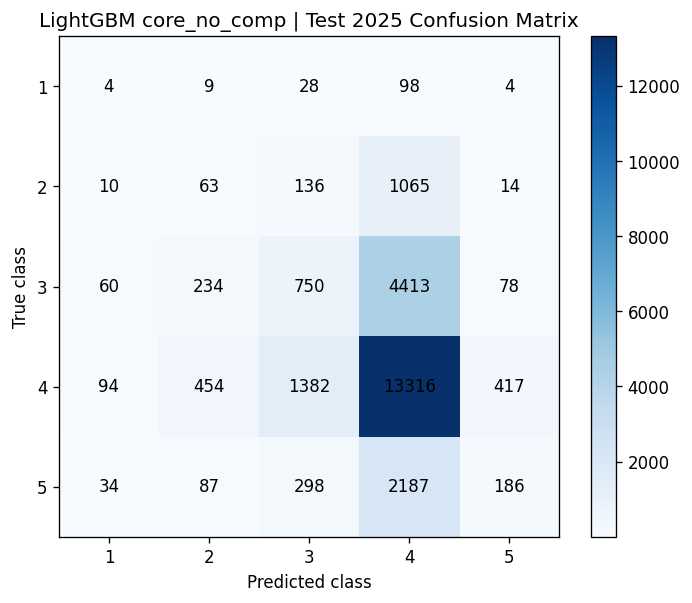

,1,2,3,4,5
1,2.8,6.3,19.6,68.5,2.8
2,0.8,4.9,10.6,82.7,1.1
3,1.1,4.2,13.6,79.7,1.4
4,0.6,2.9,8.8,85.0,2.7
5,1.2,3.1,10.7,78.3,6.7


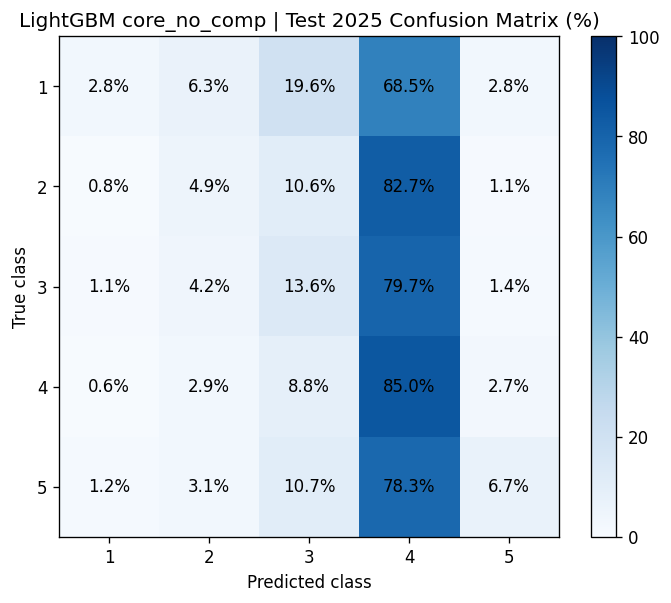

c:\Users\davis\OneDrive\Documents\VS Code Repos\DSBA-6211-Stack-overflow-Survey-Analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:991: RuntimeWarning: invalid value encountered in scalar divide
  k = xp.sum(w_mat * confusion) / xp.sum(w_mat * expected)
c:\Users\davis\OneDrive\Documents\VS Code Repos\DSBA-6211-Stack-overflow-Survey-Analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:991: RuntimeWarning: invalid value encountered in scalar divide
  k = xp.sum(w_mat * confusion) / xp.sum(w_mat * expected)
c:\Users\davis\OneDrive\Documents\VS Code Repos\DSBA-6211-Stack-overflow-Survey-Analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:991: RuntimeWarning: invalid value encountered in scalar divide
  k = xp.sum(w_mat * confusion) / xp.sum(w_mat * expected)
c:\Users\davis\OneDrive\Documents\VS Code Repos\DSBA-6211-Stack-overflow-Survey-Analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:991: RuntimeWarning: invalid value enco

Top regions by sample size:


,region,rows,accuracy,macro_f1,weighted_f1,qwk,adjacent_error_rate,far_miss_rate,recall_1,recall_2,recall_3,recall_4,recall_5
3,Europe,12159,0.628588,0.176843,0.508387,0.023981,0.312361,0.059051,0.000000,0.009788,0.017743,0.969452,0.034840
1,Americas,7309,0.583801,0.188284,0.485069,0.049076,0.344644,0.071556,0.000000,0.005236,0.036390,0.917501,0.087858
2,Asia,3797,0.414011,0.215710,0.410402,0.072723,0.458257,0.127732,0.000000,0.098901,0.561000,0.453358,0.048055
4,NaN,786,0.197201,0.166002,0.240671,0.059370,0.281170,0.521628,0.285714,0.659091,0.095238,0.195900,0.186916
5,Oceania,747,0.626506,0.189856,0.505373,0.067194,0.326640,0.046854,0.000000,0.000000,0.000000,0.974468,0.112360
0,Africa,623,0.343499,0.235975,0.361634,0.107868,0.426966,0.229535,0.181818,0.210526,0.440476,0.375776,0.107143


Top countries by sample size:


,country_clean,rows,accuracy,macro_f1,weighted_f1,qwk,adjacent_error_rate,far_miss_rate,recall_1,recall_2,recall_3,recall_4,recall_5
156,United States,4945,0.580384,0.186640,0.474069,0.053486,0.345804,0.073812,0.000000,0.003610,0.015873,0.924925,0.117986
52,Germany,2121,0.632720,0.179653,0.505790,0.019540,0.295615,0.071664,0.000000,0.007246,0.008421,0.980812,0.054795
62,India,1632,0.378676,0.180806,0.349610,0.045580,0.495711,0.125613,0.000000,0.000000,0.738149,0.318694,0.036866
155,United Kingdom,1466,0.584584,0.185364,0.461496,0.039724,0.341746,0.073670,0.000000,0.011236,0.008427,0.954494,0.102941
49,France,1016,0.608268,0.164311,0.484246,0.036274,0.324803,0.066929,0.000000,0.000000,0.000000,0.957878,0.040000
27,Canada,916,0.631004,0.166762,0.511691,0.029545,0.318777,0.050218,0.000000,0.000000,0.000000,0.961474,0.036364
94,NaN,786,0.197201,0.166002,0.240671,0.059370,0.281170,0.521628,0.285714,0.659091,0.095238,0.195900,0.186916
153,Ukraine,708,0.648305,0.167230,0.524278,0.023982,0.320621,0.031073,0.000000,0.000000,0.027397,0.982721,0.000000
118,Poland,652,0.615031,0.159239,0.474238,0.008133,0.312883,0.072086,0.000000,0.000000,0.018405,0.997494,0.000000
103,Netherlands,627,0.711324,0.166263,0.601940,0.012700,0.256778,0.031898,0.000000,0.000000,0.000000,0.982379,0.000000


In [22]:
# Inspect the untouched 2025 test set with a confusion matrix and two subgroup cuts
y_test = test_df[SAT_TARGET]
y_pred = selected_result['test_pred']

conf_df = pd.DataFrame(confusion_matrix(y_test, y_pred, labels=SAT_LABELS), index=SAT_LABELS, columns=SAT_LABELS)
display(conf_df)

plt.figure(figsize=(6, 5))
plt.imshow(conf_df, cmap='Blues')
plt.title(f"{selected_setup} | Test 2025 Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(range(len(conf_df.columns)), conf_df.columns)
plt.yticks(range(len(conf_df.index)), conf_df.index)
for i in range(conf_df.shape[0]):
    for j in range(conf_df.shape[1]):
        plt.text(j, i, conf_df.iloc[i, j], ha='center', va='center', color='black')
plt.colorbar()
plt.tight_layout()
plt.show()

# Add a row-normalized view so lower-label agreement is visible even when counts are smaller
conf_pct_df = conf_df.div(conf_df.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0) * 100
display(conf_pct_df.round(1))

plt.figure(figsize=(6, 5))
plt.imshow(conf_pct_df, cmap='Blues', vmin=0, vmax=100)
plt.title(f"{selected_setup} | Test 2025 Confusion Matrix (%)")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(range(len(conf_pct_df.columns)), conf_pct_df.columns)
plt.yticks(range(len(conf_pct_df.index)), conf_pct_df.index)
for i in range(conf_pct_df.shape[0]):
    for j in range(conf_pct_df.shape[1]):
        plt.text(j, i, f"{conf_pct_df.iloc[i, j]:.1f}%", ha='center', va='center', color='black')
plt.colorbar()
plt.tight_layout()
plt.show()

# Keep the subgroup scoring local to this diagnostics block because it is only used here
def subgroup_metrics(frame, y_true, y_pred, group_cols):
    data = frame.loc[:, group_cols].copy()
    data['y_true'] = pd.Series(y_true, index=frame.index).astype(int)
    data['y_pred'] = pd.Series(y_pred, index=frame.index).astype(int)
    rows = []

    for key, sub in data.groupby(group_cols, dropna=False):
        if len(group_cols) == 1:
            key = [key[0] if isinstance(key, tuple) else key]
        else:
            key = list(key)
        row = dict(zip(group_cols, key, strict=False))
        row['rows'] = len(sub)
        row.update(score_satisfaction(sub['y_true'], sub['y_pred']))
        rows.append(row)

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    sort_cols = []
    for col in group_cols:
        sort_col = f'__sort_{col}'
        out[sort_col] = out[col].astype('string').fillna('Missing')
        sort_cols.append(sort_col)

    return out.sort_values(sort_cols).drop(columns=sort_cols).reset_index(drop=True)


region_diag = subgroup_metrics(test_df, y_test, y_pred, ['region']).sort_values('rows', ascending=False)
country_diag = subgroup_metrics(test_df, y_test, y_pred, ['country_clean']).sort_values('rows', ascending=False)

print("Top regions by sample size:")
display(region_diag.head(10))
print("Top countries by sample size:")
display(country_diag.head(15))


In [18]:
# Collapse the 5-class output into a satisfied vs not-satisfied view so threshold behavior is easy to inspect
binary_diag = (
    test_df
    .assign(
        y_true_binary=test_df[SAT_BINARY],
        y_pred_binary=(selected_result['test_pred'] >= SAT_BINARY_THRESHOLD).astype(int)
    )
)

binary_metrics = {
    'accuracy': accuracy_score(binary_diag['y_true_binary'], binary_diag['y_pred_binary']),
    'macro_f1': f1_score(binary_diag['y_true_binary'], binary_diag['y_pred_binary'], average='macro', zero_division=0),
    'weighted_f1': f1_score(binary_diag['y_true_binary'], binary_diag['y_pred_binary'], average='weighted', zero_division=0),
    'qwk': cohen_kappa_score(binary_diag['y_true_binary'], binary_diag['y_pred_binary'], weights='quadratic')
}

print("Binary diagnostic threshold: >= 4")
display(pd.DataFrame([binary_metrics]).round(4))


Binary diagnostic threshold: >= 4


,accuracy,macro_f1,weighted_f1,qwk
0,0.6845,0.5223,0.6481,0.0687


## Rolling-Origin Check

This is the final stability check for the selected family. I do not want to endlessly retune every model across every possible split, but I do want to see whether the selected model stays competitive as the training window expands over time.


In [19]:
# Check whether the selected family stays competitive as the training window expands
rolling_family = 'catboost' if selected_setup == 'CatBoost core_no_comp' else 'lightgbm'
rolling_rows = []
rolling_years = sorted(year for year in sat_df['survey_year'].dropna().unique() if year >= 2015)

for valid_year in rolling_years:
    if valid_year > 2024:
        continue

    train_years = [year for year in rolling_years if year < valid_year]
    if not train_years:
        continue

    train_fold = sat_df.loc[sat_df['survey_year'].isin(train_years)].copy()
    valid_fold = sat_df.loc[sat_df['survey_year'] == valid_year].copy()
    if train_fold.empty or valid_fold.empty:
        continue

    if rolling_family == 'catboost':
        result = fit_catboost_multiclass(train_fold, valid_fold, valid_fold, core_cat, core_num, params=cat_params)
    else:
        result = fit_lgbm_multiclass(train_fold, valid_fold, valid_fold, core_cat, core_num, params=lgb_params)

    rolling_rows.append({
        'train_years': ','.join(map(str, train_years)),
        'valid_year': valid_year,
        **result['valid_metrics']
    })

rolling_main = pd.DataFrame(rolling_rows)
display(rolling_main)


,train_years,valid_year,accuracy,macro_f1,weighted_f1,qwk,adjacent_error_rate,far_miss_rate,recall_1,recall_2,recall_3,recall_4,recall_5
0,2015,2016,0.302594,0.224459,0.313466,0.074096,0.369529,0.327877,0.078406,0.194739,0.225837,0.256333,0.436685
1,"2015,2016",2017,0.231411,0.181352,0.262973,0.049236,0.423250,0.345339,0.097345,0.224193,0.228622,0.196551,0.447137
2,"2015,2016,2017",2018,0.232923,0.153554,0.199032,0.048042,0.454544,0.312533,0.045712,0.068829,0.071445,0.138256,0.783504
3,"2015,2016,2017,2018",2019,0.319614,0.220805,0.292676,0.106990,0.413114,0.267273,0.035177,0.060924,0.258661,0.572719,0.252426
4,"2015,2016,2017,2018,2019",2020,0.297459,0.180051,0.220895,0.065137,0.431199,0.271341,0.022748,0.054334,0.213592,0.765606,0.073158
5,"2015,2016,2017,2018,2019,2020",2024,0.355729,0.187166,0.377418,0.057799,0.454734,0.189537,0.022222,0.059940,0.081965,0.480737,0.511239


## Next Steps

- keep `LightGBM core_no_comp` as the canonical satisfaction benchmark with the promoted age and career-stage features already in the main spec
- keep compensation as a same-sample sensitivity only, since it helps when observed but changes the modeled population
- keep `undergrad_major` as a monitored side candidate rather than part of the main spec because the lift is too small and mixed to justify locking it in
- keep later-wave context features like `industry_clean`, `ic_or_pm_clean`, AI fields, and learning fields out of the canonical cross-year model because their support is too uneven across the training window
- present the final result honestly: the dataset contains some predictive signal for job satisfaction, but even after the final feature audit the model is still modest


## Scratch Test: Alt-Equal-Width Plus Compensation

This is a notebook-only scratch check that combines the stronger alternate equal-width satisfaction mapping with the `LightGBM core_with_comp` feature set. It changes the modeled population because compensation must be observed, so treat it as a sensitivity rather than a replacement for the main headline model.


Scratch comparison against the current chosen model:


,setup,valid_qwk,valid_macro_f1,test_qwk,test_macro_f1,test_weighted_f1,test_accuracy,test_adjacent_error_rate,test_far_miss_rate
1,LightGBM core_with_comp + alt_equal_width,0.086460,0.220287,0.101726,0.230473,0.377605,0.391159,0.422026,0.186814
0,LightGBM core_no_comp,0.055576,0.187209,0.065655,0.219625,0.501606,0.563274,0.345698,0.091027


Scratch sample sizes:


,setup,train_rows,valid_rows,test_rows
0,LightGBM core_with_comp + alt_equal_width,180317,14780,18596


,1,2,3,4,5
1,13,50,74,259,107
2,30,91,182,628,219
3,65,254,506,1946,715
4,163,523,1000,5176,2153
5,67,205,449,2233,1488


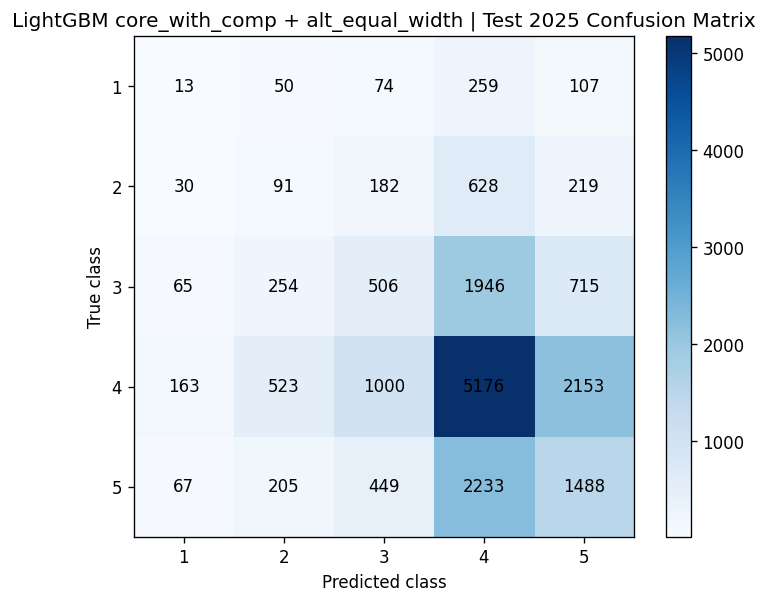

,1,2,3,4,5
1,2.6,9.9,14.7,51.5,21.3
2,2.6,7.9,15.8,54.6,19.0
3,1.9,7.3,14.5,55.8,20.5
4,1.8,5.8,11.1,57.4,23.9
5,1.5,4.6,10.1,50.3,33.5


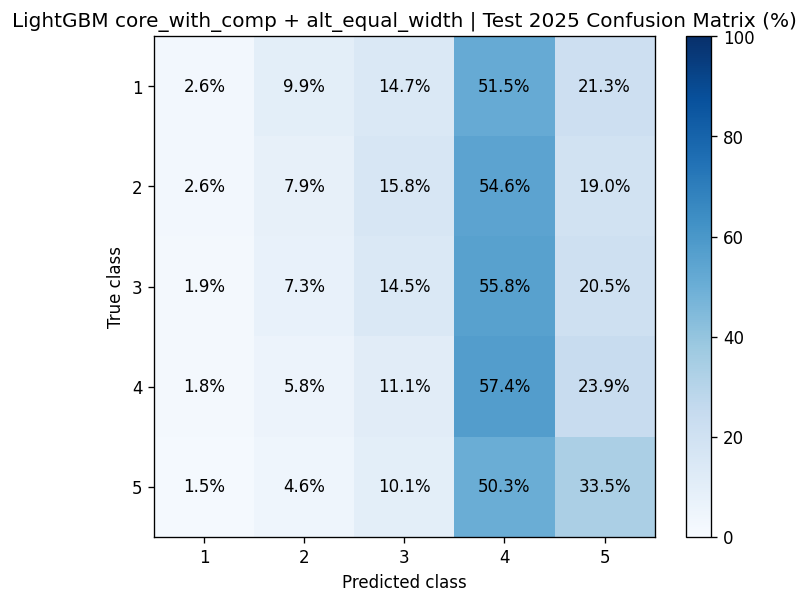

In [21]:
# Combine the alternate equal-width target mapping with the compensation-aware LightGBM spec
scratch_df = build_satisfaction_frame(clean_core, numeric_scheme='alt_equal_width', drop_2018=False)
scratch_df = scratch_df.loc[scratch_df['log_comp_real_2025'].notna()].copy()
scratch_role_cols = sorted(col for col in scratch_df.columns if col.startswith('role_') and col not in {'role_family', 'role_family_count'})
scratch_feature_sets = build_feature_sets(scratch_role_cols)
scratch_train, scratch_valid, scratch_test = split_years(scratch_df, SAT_TRAIN_YEARS, SAT_VALID_YEAR, SAT_TEST_YEAR)

scratch_result = fit_lgbm_multiclass(
    scratch_train,
    scratch_valid,
    scratch_test,
    scratch_feature_sets['core_with_comp_cat'],
    scratch_feature_sets['core_with_comp_num'],
    params=lgb_params
)

# Compare the scratch run directly against the current chosen model
scratch_comparison = pd.DataFrame([
    result_row(selected_setup, selected_result),
    result_row('LightGBM core_with_comp + alt_equal_width', scratch_result)
]).sort_values(['valid_qwk', 'valid_macro_f1'], ascending=False)

print("Scratch comparison against the current chosen model:")
display(scratch_comparison)

print("Scratch sample sizes:")
display(pd.DataFrame([
    {
        'setup': 'LightGBM core_with_comp + alt_equal_width',
        'train_rows': len(scratch_train),
        'valid_rows': len(scratch_valid),
        'test_rows': len(scratch_test)
    }
]))

# Show the confusion matrix heatmap for the scratch model on the untouched 2025 test rows
scratch_conf_df = pd.DataFrame(
    confusion_matrix(scratch_test[SAT_TARGET], scratch_result['test_pred'], labels=SAT_LABELS),
    index=SAT_LABELS,
    columns=SAT_LABELS
)
display(scratch_conf_df)

plt.figure(figsize=(6, 5))
plt.imshow(scratch_conf_df, cmap='Blues')
plt.title("LightGBM core_with_comp + alt_equal_width | Test 2025 Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(range(len(scratch_conf_df.columns)), scratch_conf_df.columns)
plt.yticks(range(len(scratch_conf_df.index)), scratch_conf_df.index)
for i in range(scratch_conf_df.shape[0]):
    for j in range(scratch_conf_df.shape[1]):
        plt.text(j, i, scratch_conf_df.iloc[i, j], ha='center', va='center', color='black')
plt.colorbar()
plt.tight_layout()
plt.show()

# Add the row-normalized scratch view to compare class agreement without the raw-count imbalance
scratch_conf_pct_df = scratch_conf_df.div(scratch_conf_df.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0) * 100
display(scratch_conf_pct_df.round(1))

plt.figure(figsize=(6, 5))
plt.imshow(scratch_conf_pct_df, cmap='Blues', vmin=0, vmax=100)
plt.title("LightGBM core_with_comp + alt_equal_width | Test 2025 Confusion Matrix (%)")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(range(len(scratch_conf_pct_df.columns)), scratch_conf_pct_df.columns)
plt.yticks(range(len(scratch_conf_pct_df.index)), scratch_conf_pct_df.index)
for i in range(scratch_conf_pct_df.shape[0]):
    for j in range(scratch_conf_pct_df.shape[1]):
        plt.text(j, i, f"{scratch_conf_pct_df.iloc[i, j]:.1f}%", ha='center', va='center', color='black')
plt.colorbar()
plt.tight_layout()
plt.show()
